<a href="https://colab.research.google.com/github/Karthik5412/Shopping-Cart/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/flipkart_com-ecommerce_sample.csv')
df.head()

,uniq_id,crawl_timestamp,product_url,product_name,product_category_tree,pid,retail_price,discounted_price,image,is_FK_Advantage_product,description,product_rating,overall_rating,brand,product_specifications
0,c2d766ca982eca8304150849735ffef9,2016-03-25 22:59:23 +0000,http://www.flipkart.com/alisha-solid-women-s-c...,Alisha Solid Women's Cycling Shorts,"[""Clothing >> Women's Clothing >> Lingerie, Sl...",SRTEH2FF9KEDEFGF,999.0,379.0,"[""http://img5a.flixcart.com/image/short/u/4/a/...",False,Key Features of Alisha Solid Women's Cycling S...,No rating available,No rating available,Alisha,"{""product_specification""=>[{""key""=>""Number of ..."
1,7f7036a6d550aaa89d34c77bd39a5e48,2016-03-25 22:59:23 +0000,http://www.flipkart.com/fabhomedecor-fabric-do...,FabHomeDecor Fabric Double Sofa Bed,"[""Furniture >> Living Room Furniture >> Sofa B...",SBEEH3QGU7MFYJFY,32157.0,22646.0,"[""http://img6a.flixcart.com/image/sofa-bed/j/f...",False,FabHomeDecor Fabric Double Sofa Bed (Finish Co...,No rating available,No rating available,FabHomeDecor,"{""product_specification""=>[{""key""=>""Installati..."
2,f449ec65dcbc041b6ae5e6a32717d01b,2016-03-25 22:59:23 +0000,http://www.flipkart.com/aw-bellies/p/itmeh4grg...,AW Bellies,"[""Footwear >> Women's Footwear >> Ballerinas >...",SHOEH4GRSUBJGZXE,999.0,499.0,"[""http://img5a.flixcart.com/image/shoe/7/z/z/r...",False,Key Features of AW Bellies Sandals Wedges Heel...,No rating available,No rating available,AW,"{""product_specification""=>[{""key""=>""Ideal For""..."
3,0973b37acd0c664e3de26e97e5571454,2016-03-25 22:59:23 +0000,http://www.flipkart.com/alisha-solid-women-s-c...,Alisha Solid Women's Cycling Shorts,"[""Clothing >> Women's Clothing >> Lingerie, Sl...",SRTEH2F6HUZMQ6SJ,699.0,267.0,"[""http://img5a.flixcart.com/image/short/6/2/h/...",False,Key Features of Alisha Solid Women's Cycling S...,No rating available,No rating available,Alisha,"{""product_specification""=>[{""key""=>""Number of ..."
4,bc940ea42ee6bef5ac7cea3fb5cfbee7,2016-03-25 22:59:23 +0000,http://www.flipkart.com/sicons-all-purpose-arn...,Sicons All Purpose Arnica Dog Shampoo,"[""Pet Supplies >> Grooming >> Skin & Coat Care...",PSOEH3ZYDMSYARJ5,220.0,210.0,"[""http://img5a.flixcart.com/image/pet-shampoo/...",False,Specifications of Sicons All Purpose Arnica Do...,No rating available,No rating available,Sicons,"{""product_specification""=>[{""key""=>""Pet Type"",..."


In [ ]:
print(df.shape)
df.info()

(20000, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   uniq_id                  20000 non-null  object 
 1   crawl_timestamp          20000 non-null  object 
 2   product_url              20000 non-null  object 
 3   product_name             20000 non-null  object 
 4   product_category_tree    20000 non-null  object 
 5   pid                      20000 non-null  object 
 6   retail_price             19922 non-null  float64
 7   discounted_price         19922 non-null  float64
 8   image                    19997 non-null  object 
 9   is_FK_Advantage_product  20000 non-null  bool   
 10  description              19998 non-null  object 
 11  product_rating           20000 non-null  object 
 12  overall_rating           20000 non-null  object 
 13  brand                    14136 non-null  object 
 14  product_sp

In [ ]:
unwanted_cols = ['product_url','pid','is_FK_Advantage_product','uniq_id','crawl_timestamp','image','product_rating','overall_rating', 'brand', 'product_specifications']

df = df.drop(columns= unwanted_cols)
df.head()

,product_name,product_category_tree,retail_price,discounted_price,description
0,Alisha Solid Women's Cycling Shorts,"[""Clothing >> Women's Clothing >> Lingerie, Sl...",999.0,379.0,Key Features of Alisha Solid Women's Cycling S...
1,FabHomeDecor Fabric Double Sofa Bed,"[""Furniture >> Living Room Furniture >> Sofa B...",32157.0,22646.0,FabHomeDecor Fabric Double Sofa Bed (Finish Co...
2,AW Bellies,"[""Footwear >> Women's Footwear >> Ballerinas >...",999.0,499.0,Key Features of AW Bellies Sandals Wedges Heel...
3,Alisha Solid Women's Cycling Shorts,"[""Clothing >> Women's Clothing >> Lingerie, Sl...",699.0,267.0,Key Features of Alisha Solid Women's Cycling S...
4,Sicons All Purpose Arnica Dog Shampoo,"[""Pet Supplies >> Grooming >> Skin & Coat Care...",220.0,210.0,Specifications of Sicons All Purpose Arnica Do...


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   product_name           20000 non-null  object 
 1   product_category_tree  20000 non-null  object 
 2   retail_price           19922 non-null  float64
 3   discounted_price       19922 non-null  float64
 4   description            19998 non-null  object 
dtypes: float64(2), object(3)
memory usage: 781.4+ KB


In [ ]:
df = df.dropna()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19920 entries, 0 to 19999
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   product_name           19920 non-null  object 
 1   product_category_tree  19920 non-null  object 
 2   retail_price           19920 non-null  float64
 3   discounted_price       19920 non-null  float64
 4   description            19920 non-null  object 
dtypes: float64(2), object(3)
memory usage: 933.8+ KB


In [ ]:
df.loc[2,'product_category_tree']

'["Footwear >> Women\'s Footwear >> Ballerinas >> AW Bellies"]'

In [ ]:
df['product_category_tree'] = df['product_category_tree'].str.replace(r'[\[\]"]', '', regex=True)
df['category_1'] = df['product_category_tree'].str.split('>>').str[0]
df['category_2'] = df['product_category_tree'].str.split('>>').str[1]
df = df.drop(columns='product_category_tree')
df.head()

,product_name,retail_price,discounted_price,description,category_1,category_2
0,Alisha Solid Women's Cycling Shorts,999.0,379.0,Key Features of Alisha Solid Women's Cycling S...,Clothing,Women's Clothing
1,FabHomeDecor Fabric Double Sofa Bed,32157.0,22646.0,FabHomeDecor Fabric Double Sofa Bed (Finish Co...,Furniture,Living Room Furniture
2,AW Bellies,999.0,499.0,Key Features of AW Bellies Sandals Wedges Heel...,Footwear,Women's Footwear
3,Alisha Solid Women's Cycling Shorts,699.0,267.0,Key Features of Alisha Solid Women's Cycling S...,Clothing,Women's Clothing
4,Sicons All Purpose Arnica Dog Shampoo,220.0,210.0,Specifications of Sicons All Purpose Arnica Do...,Pet Supplies,Grooming


In [ ]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
stop_words = set(stopwords.words('english'))
lematizer = WordNetLemmatizer()

In [ ]:
def preprocessing_text(data : str) -> str:

    #Lower Case
    data = str(data).lower()

    #Remove punctuations
    data = re.sub(r'[^a-zA-z\s]', "",data)

    #Words split
    words = data.split()

    #removing stopwords
    words = [word for word in words if word not in stop_words]

    #Lematization
    words = [lematizer.lemmatize(word) for word in words]

    return ' '.join(words)

In [ ]:
df['description'] = df['description'].apply(preprocessing_text)
df['product_name'] = df['product_name'].apply(preprocessing_text)
df['category_2'] = df['category_2'].astype(object).apply(preprocessing_text)

df.head()

,product_name,retail_price,discounted_price,description,category_1,category_2
0,alisha solid womens cycling short,999.0,379.0,key feature alisha solid womens cycling short ...,Clothing,womens clothing
1,fabhomedecor fabric double sofa bed,32157.0,22646.0,fabhomedecor fabric double sofa bed finish col...,Furniture,living room furniture
2,aw belly,999.0,499.0,key feature aw belly sandal wedge heel casuals...,Footwear,womens footwear
3,alisha solid womens cycling short,699.0,267.0,key feature alisha solid womens cycling short ...,Clothing,womens clothing
4,sicons purpose arnica dog shampoo,220.0,210.0,specification sicons purpose arnica dog shampo...,Pet Supplies,grooming


In [ ]:
df

,product_name,retail_price,discounted_price,description,category_1,category_2
0,alisha solid womens cycling short,999.0,379.0,key feature alisha solid womens cycling short ...,Clothing,womens clothing
1,fabhomedecor fabric double sofa bed,32157.0,22646.0,fabhomedecor fabric double sofa bed finish col...,Furniture,living room furniture
2,aw belly,999.0,499.0,key feature aw belly sandal wedge heel casuals...,Footwear,womens footwear
3,alisha solid womens cycling short,699.0,267.0,key feature alisha solid womens cycling short ...,Clothing,womens clothing
4,sicons purpose arnica dog shampoo,220.0,210.0,specification sicons purpose arnica dog shampo...,Pet Supplies,grooming
...,...,...,...,...,...,...
19995,walldesign small vinyl sticker,1500.0,730.0,buy walldesign small vinyl sticker r online wa...,Baby Care,baby kid gift
19996,wallmantra large vinyl sticker sticker,1429.0,1143.0,buy wallmantra large vinyl sticker sticker r o...,Baby Care,baby kid gift
19997,elite collection medium acrylic sticker,1299.0,999.0,buy elite collection medium acrylic sticker r ...,Baby Care,baby kid gift
19998,elite collection medium acrylic sticker,1499.0,1199.0,buy elite collection medium acrylic sticker r ...,Baby Care,baby kid gift


In [ ]:
df['Final pharse'] = df['product_name'] + df['description'] +df['category_2']
df

,product_name,retail_price,discounted_price,description,category_1,category_2,Final pharse
0,alisha solid womens cycling short,999.0,379.0,key feature alisha solid womens cycling short ...,Clothing,womens clothing,alisha solid womens cycling shortkey feature a...
1,fabhomedecor fabric double sofa bed,32157.0,22646.0,fabhomedecor fabric double sofa bed finish col...,Furniture,living room furniture,fabhomedecor fabric double sofa bedfabhomedeco...
2,aw belly,999.0,499.0,key feature aw belly sandal wedge heel casuals...,Footwear,womens footwear,aw bellykey feature aw belly sandal wedge heel...
3,alisha solid womens cycling short,699.0,267.0,key feature alisha solid womens cycling short ...,Clothing,womens clothing,alisha solid womens cycling shortkey feature a...
4,sicons purpose arnica dog shampoo,220.0,210.0,specification sicons purpose arnica dog shampo...,Pet Supplies,grooming,sicons purpose arnica dog shampoospecification...
...,...,...,...,...,...,...,...
19995,walldesign small vinyl sticker,1500.0,730.0,buy walldesign small vinyl sticker r online wa...,Baby Care,baby kid gift,walldesign small vinyl stickerbuy walldesign s...
19996,wallmantra large vinyl sticker sticker,1429.0,1143.0,buy wallmantra large vinyl sticker sticker r o...,Baby Care,baby kid gift,wallmantra large vinyl sticker stickerbuy wall...
19997,elite collection medium acrylic sticker,1299.0,999.0,buy elite collection medium acrylic sticker r ...,Baby Care,baby kid gift,elite collection medium acrylic stickerbuy eli...
19998,elite collection medium acrylic sticker,1499.0,1199.0,buy elite collection medium acrylic sticker r ...,Baby Care,baby kid gift,elite collection medium acrylic stickerbuy eli...


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
tfidf = TfidfVectorizer(max_features= 5000, ngram_range=(1,2), stop_words= 'english')

In [ ]:
matrix = tfidf.fit_transform(df['Final pharse'])

In [ ]:
matrix

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 825115 stored elements and shape (19920, 5000)>

In [ ]:
n = len(df['category_1'].unique())

In [ ]:
from sklearn.cluster import KMeans
model = KMeans(n_clusters= n, init= 'k-means++')

In [ ]:
clusters = model.fit_predict(matrix)

In [ ]:
clusters

array([230, 154, 122, ..., 150, 150, 150], dtype=int32)

In [ ]:
df['clusters'] = clusters
df

,product_name,retail_price,discounted_price,description,category_1,category_2,Final pharse,clusters
0,alisha solid womens cycling short,999.0,379.0,key feature alisha solid womens cycling short ...,Clothing,womens clothing,alisha solid womens cycling shortkey feature a...,230
1,fabhomedecor fabric double sofa bed,32157.0,22646.0,fabhomedecor fabric double sofa bed finish col...,Furniture,living room furniture,fabhomedecor fabric double sofa bedfabhomedeco...,154
2,aw belly,999.0,499.0,key feature aw belly sandal wedge heel casuals...,Footwear,womens footwear,aw bellykey feature aw belly sandal wedge heel...,122
3,alisha solid womens cycling short,699.0,267.0,key feature alisha solid womens cycling short ...,Clothing,womens clothing,alisha solid womens cycling shortkey feature a...,230
4,sicons purpose arnica dog shampoo,220.0,210.0,specification sicons purpose arnica dog shampo...,Pet Supplies,grooming,sicons purpose arnica dog shampoospecification...,257
...,...,...,...,...,...,...,...,...
19995,walldesign small vinyl sticker,1500.0,730.0,buy walldesign small vinyl sticker r online wa...,Baby Care,baby kid gift,walldesign small vinyl stickerbuy walldesign s...,40
19996,wallmantra large vinyl sticker sticker,1429.0,1143.0,buy wallmantra large vinyl sticker sticker r o...,Baby Care,baby kid gift,wallmantra large vinyl sticker stickerbuy wall...,69
19997,elite collection medium acrylic sticker,1299.0,999.0,buy elite collection medium acrylic sticker r ...,Baby Care,baby kid gift,elite collection medium acrylic stickerbuy eli...,150
19998,elite collection medium acrylic sticker,1499.0,1199.0,buy elite collection medium acrylic sticker r ...,Baby Care,baby kid gift,elite collection medium acrylic stickerbuy eli...,150


<Axes: xlabel='retail_price', ylabel='discounted_price'>

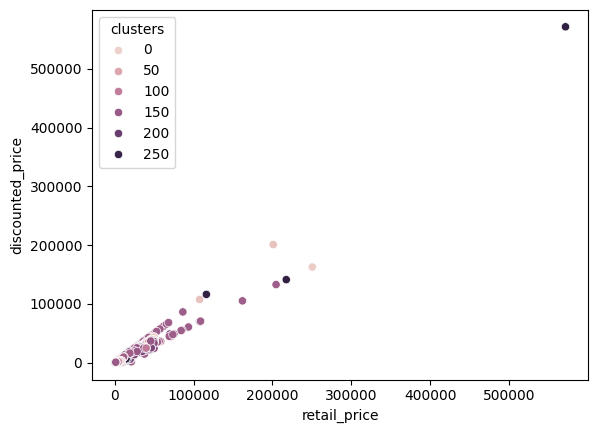

In [ ]:
sns.scatterplot(x= df['retail_price'], y= df['discounted_price'], hue= df['clusters'])

In [ ]:
import pickle

pickle.dump(preprocessing_text, open('preprocessing.plk', 'wb'))
pickle.dump(tfidf, open('tfidf.plk', 'wb'))
pickle.dump(model, open('kmeans.plk', 'wb'))

df.to_csv('final_dataset')